# Comprehensive EDA — FinanceBench (Task T04)

Profiles the 150-example open-source FinanceBench QA set for our study of **hallucination in
RAG-based financial QA**, and produces the figures + written findings for the paper's Data section.

This notebook follows a 10-part checklist: (1) dataset overview, (2) question analysis,
(3) answer analysis, (4) evidence/context, (5) source documents, (6) company/domain,
(7) retrieval-difficulty proxies, (8) linguistic complexity, (9) data-quality checks,
(10) hallucination pre-analysis — plus a visualization summary.

**Inputs** (run `python src/download_data.py` first):
- `data/raw/financebench_open_source.jsonl`, `data/raw/financebench_document_information.jsonl`
- `data/pdfs/*.pdf` (used for page counts)

**Outputs:** figures + `eda_summary.md` under `results/`.

In [1]:
import re
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA = ROOT / "data" / "raw"
PDFS = ROOT / "data" / "pdfs"
RESULTS = ROOT / "results"
RESULTS.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 200
plt.rcParams["savefig.bbox"] = "tight"
PALETTE = "viridis"

def save(fig, name):
    fig.tight_layout()
    fig.savefig(RESULTS / name)
    return name

print("repo root:", ROOT)

repo root: /Users/bhalchandra/SEM3_NEU/NLP/project/finrag-hallucination


## 0. Load data + feature engineering
All derived columns are computed once here, then reused across sections.

In [2]:
qa = pd.read_json(DATA / "financebench_open_source.jsonl", lines=True)
doc_info = pd.read_json(DATA / "financebench_document_information.jsonl", lines=True)
print("QA records:", len(qa), "| columns:", list(qa.columns))

QA records: 150 | columns: ['financebench_id', 'company', 'doc_name', 'question_type', 'question_reasoning', 'domain_question_num', 'question', 'answer', 'justification', 'dataset_subset_label', 'evidence', 'gics_sector', 'doc_type', 'doc_period', 'doc_link']


In [3]:
# --- Evidence parsing -------------------------------------------------------
def ev_concat(ev):
    return " ".join(str(i.get("evidence_text", "")) for i in ev)

def ev_page_list(ev):
    return [i.get("evidence_page_num") for i in ev if i.get("evidence_page_num") is not None]

def ev_doc_set(ev):
    return {i.get("doc_name") for i in ev if i.get("doc_name")}

qa["evidence_text_all"] = qa["evidence"].apply(ev_concat)
qa["evidence_pages"]    = qa["evidence"].apply(ev_page_list)
qa["n_evidence_items"]  = qa["evidence"].apply(len)
qa["n_evidence_pages"]  = qa["evidence_pages"].apply(lambda p: len(set(p)))
qa["evidence_docs"]     = qa["evidence"].apply(ev_doc_set)
qa["n_evidence_docs"]   = qa["evidence_docs"].apply(len)
qa["multi_page"]        = qa["n_evidence_pages"] > 1
qa["multi_document"]    = qa["n_evidence_docs"] > 1

# --- Lengths ----------------------------------------------------------------
qa["question_words"] = qa["question"].astype(str).str.split().str.len()
qa["answer_words"]   = qa["answer"].astype(str).str.split().str.len()
qa["evidence_words"] = qa["evidence_text_all"].str.split().str.len()

# --- PDF page counts (document length) --------------------------------------
import fitz  # PyMuPDF
doc_pages = {}
for p in sorted(PDFS.glob("*.pdf")):
    try:
        d = fitz.open(p); doc_pages[p.stem] = d.page_count; d.close()
    except Exception as e:
        print("page-count failed:", p.name, e)
qa["doc_pages"] = qa["doc_name"].map(doc_pages)
print(f"page counts for {len(doc_pages)} PDFs; coverage in QA: {qa['doc_pages'].notna().mean():.0%}")

# evidence depth: how deep in the document the (first) evidence page sits
qa["first_evidence_page"] = qa["evidence_pages"].apply(lambda p: min(p) if p else np.nan)
qa["evidence_depth_ratio"] = qa["first_evidence_page"] / qa["doc_pages"]

page counts for 84 PDFs; coverage in QA: 100%


In [4]:
# --- Answer typing ----------------------------------------------------------
num_re = re.compile(r"\d")
money_re = re.compile(r"\$|usd", re.I)
pct_re = re.compile(r"%|percent", re.I)
unit_re = re.compile(r"\b(million|billion|thousand|bn|mn)\b", re.I)
ratio_re = re.compile(r"\b\d+(\.\d+)?\s*x\b|ratio", re.I)
date_re = re.compile(r"\b(19|20)\d{2}\b|january|february|march|april|may|june|july|august|september|october|november|december|fy\d", re.I)

def answer_type(a):
    a = str(a)
    if money_re.search(a) or unit_re.search(a):
        return "monetary"
    if pct_re.search(a):
        return "percentage"
    if ratio_re.search(a):
        return "ratio"
    if date_re.search(a) and len(a.split()) <= 4:
        return "date/period"
    if num_re.search(a):
        return "other numeric"
    if a.strip().lower() in {"yes", "no"}:
        return "yes/no"
    return "text"

qa["answer_type"] = qa["answer"].apply(answer_type)
qa["is_numeric_answer"] = qa["answer"].apply(lambda a: bool(num_re.search(str(a))))
qa["answer_has_currency"] = qa["answer"].apply(lambda a: bool(money_re.search(str(a)) or unit_re.search(str(a))))
qa["answer_has_pct"] = qa["answer"].apply(lambda a: bool(pct_re.search(str(a))))

# --- Question typing (heuristic) -------------------------------------------
comp_re = re.compile(r"\b(compare|versus|vs\.?|change|increase|decrease|grow|growth|year[- ]over[- ]year|yoy|between|higher|lower|more than|less than)\b", re.I)
def question_class(row):
    q = str(row["question"]).lower()
    reasoning = str(row["question_reasoning"]).lower()
    if row["n_evidence_items"] > 1 or "logical reasoning" in reasoning:
        return "multi-step reasoning"
    if comp_re.search(q):
        return "comparative"
    if q.startswith("when") or "what year" in q or "which year" in q:
        return "date-based"
    if "numerical" in reasoning or row["is_numeric_answer"]:
        return "numerical"
    return "categorical/factual"

qa["question_class"] = qa.apply(question_class, axis=1)

# --- Financial topic clustering (keyword) -----------------------------------
TOPICS = {
    "Revenue/Sales": ["revenue", "net sales", "sales"],
    "Profit/Margin": ["margin", "operating income", "gross profit", "ebitda", "ebit", "profitab"],
    "EPS/Earnings": ["eps", "earnings per share", "earnings", "net income"],
    "Cash Flow/Capex": ["cash flow", "operating cash", "free cash", "capex", "capital expenditure"],
    "Debt/Leverage": ["debt", "leverage", "borrowing", "interest expense", "liabilit"],
    "Assets/Balance Sheet": ["assets", "inventory", "receivable", "goodwill", "equity", "balance sheet", "working capital"],
    "Dividends/Buyback": ["dividend", "buyback", "repurchase", "treasury stock"],
    "Risk/Legal": ["risk", "litigation", "lawsuit", "contingenc"],
    "Accounting/Tax": ["accounting policy", "depreciation", "amortization", "tax", "impairment"],
    "Segments/Geography": ["segment", "geograph", "region", "business unit"],
}
def topic(q):
    ql = str(q).lower()
    for name, kws in TOPICS.items():
        if any(k in ql for k in kws):
            return name
    return "Other"
qa["topic"] = qa["question"].apply(topic)

# --- Retrieval / hallucination-risk proxies --------------------------------
def numeric_tokens(s):
    return set(re.findall(r"\d[\d,]*\.?\d*", str(s).replace(",", "")))

def extractability(row):
    # 1.0 if answer is a normalized substring of evidence; else fraction of the
    # answer's numbers that appear in the evidence (numeric overlap).
    a = re.sub(r"[^a-z0-9.% ]", "", str(row["answer"]).lower()).strip()
    ev = re.sub(r"[^a-z0-9.% ]", "", row["evidence_text_all"].lower())
    if a and a in ev:
        return 1.0
    anums = numeric_tokens(row["answer"])
    if not anums:
        return 1.0 if a and a in ev else 0.0
    enums = numeric_tokens(row["evidence_text_all"])
    return len(anums & enums) / len(anums)

qa["extractability"] = qa.apply(extractability, axis=1)
qa["answer_verbatim_in_evidence"] = qa.apply(
    lambda r: bool(str(r["answer"]).strip().lower() and str(r["answer"]).strip().lower() in r["evidence_text_all"].lower()), axis=1)

neg_re = re.compile(r"\b(excluding|without|except|net of|adjusted for|other than|if |assuming|had )\b", re.I)
temporal_re = re.compile(r"\b(latest|current|most recent|today|now|as of)\b", re.I)
qa["has_negation_conditional"] = qa["question"].apply(lambda q: bool(neg_re.search(str(q))))
qa["temporal_ambiguity"] = qa["question"].apply(lambda q: bool(temporal_re.search(str(q))))
qa["needs_computation"] = qa["question_reasoning"].astype(str).str.contains("Numerical|Logical", case=False, na=False)

# table-vs-prose heuristic for evidence: high numeric-token density => table
def numeric_density(s):
    toks = str(s).split()
    if not toks:
        return 0.0
    return sum(bool(re.search(r"\d", t)) for t in toks) / len(toks)
qa["evidence_numeric_density"] = qa["evidence_text_all"].apply(numeric_density)
qa["evidence_is_table"] = qa["evidence_numeric_density"] > 0.20

print(qa[["question_class", "answer_type", "topic"]].head())
print("\nextractability mean:", round(qa["extractability"].mean(), 2),
      "| verbatim answers:", f"{qa['answer_verbatim_in_evidence'].mean():.0%}")

         question_class answer_type                 topic
0             numerical    monetary       Cash Flow/Capex
1             numerical    monetary  Assets/Balance Sheet
2  multi-step reasoning  percentage                 Other
3  multi-step reasoning  percentage         Profit/Margin
4           comparative  percentage    Segments/Geography

extractability mean: 0.27 | verbatim answers: 2%


## 1. Dataset overview & basic statistics

In [5]:
overview = {
    "QA pairs": len(qa),
    "Unique companies": qa["company"].nunique(),
    "Unique source documents": qa["doc_name"].nunique(),
    "Doc types": qa["doc_type"].nunique(),
    "GICS sectors": qa["gics_sector"].nunique(),
    "Fiscal-year range": f"{int(qa['doc_period'].min())}-{int(qa['doc_period'].max())}",
}
for k, v in overview.items():
    print(f"{k:28s}: {v}")
print("\nDoc-type counts:", qa["doc_type"].value_counts().to_dict())

QA pairs                    : 150
Unique companies            : 32
Unique source documents     : 84
Doc types                   : 4
GICS sectors                : 9
Fiscal-year range           : 2015-2024

Doc-type counts: {'10k': 112, '10q': 15, 'Earnings': 14, '8k': 9}


## 2. Question analysis

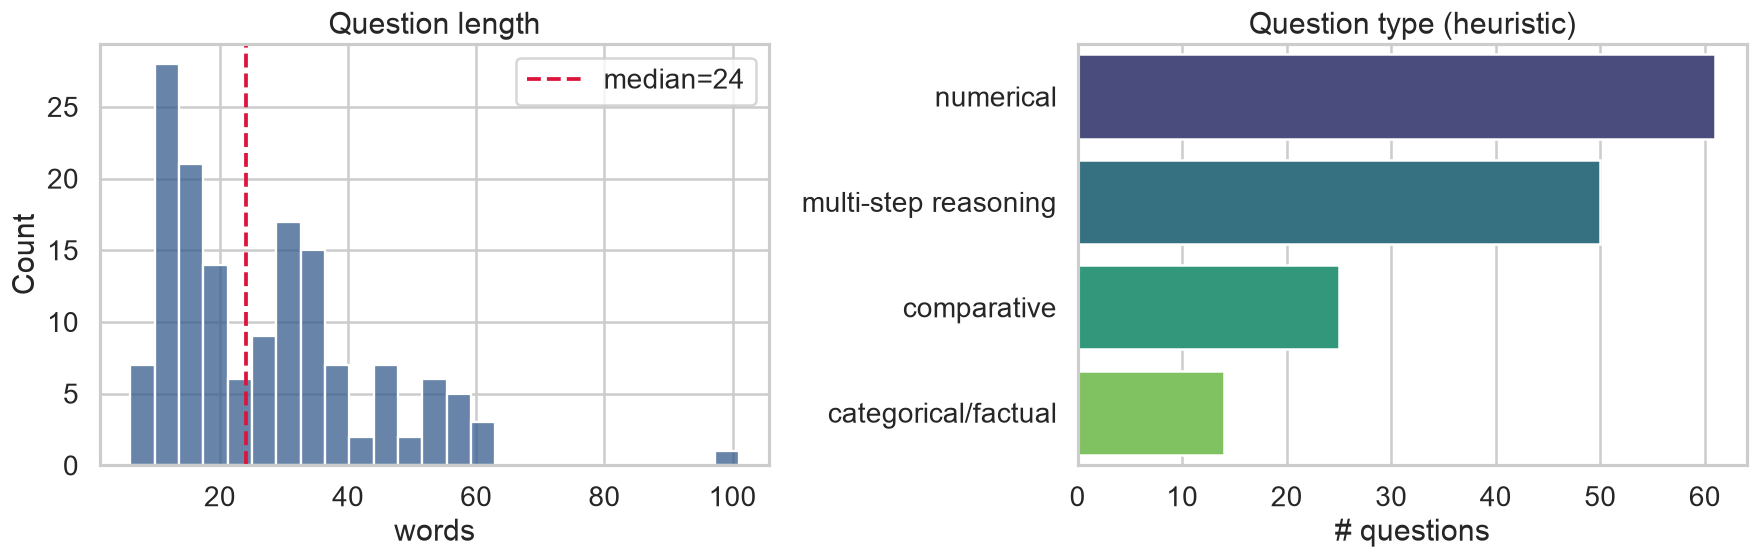

{'numerical': 61, 'multi-step reasoning': 50, 'comparative': 25, 'categorical/factual': 14}


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(qa["question_words"], bins=25, color=sns.color_palette(PALETTE)[1], ax=axes[0])
axes[0].axvline(qa["question_words"].median(), color="crimson", ls="--",
                label=f"median={qa['question_words'].median():.0f}")
axes[0].set_title("Question length"); axes[0].set_xlabel("words"); axes[0].legend()
qc = qa["question_class"].value_counts()
sns.barplot(x=qc.values, y=qc.index, palette=PALETTE, orient="h", ax=axes[1])
axes[1].set_title("Question type (heuristic)"); axes[1].set_xlabel("# questions"); axes[1].set_ylabel("")
save(fig, "fig_question_analysis.png"); plt.show()
print(qc.to_dict())

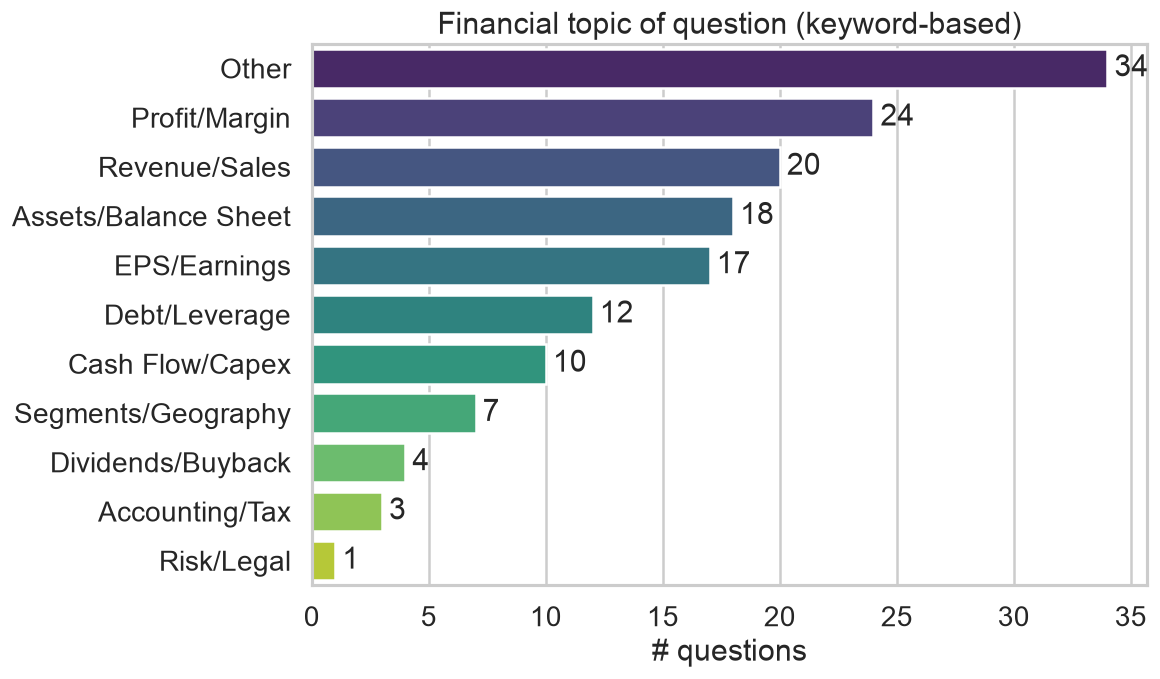

{'Other': 34, 'Profit/Margin': 24, 'Revenue/Sales': 20, 'Assets/Balance Sheet': 18, 'EPS/Earnings': 17, 'Debt/Leverage': 12, 'Cash Flow/Capex': 10, 'Segments/Geography': 7, 'Dividends/Buyback': 4, 'Accounting/Tax': 3, 'Risk/Legal': 1}


In [7]:
# Financial topic clustering
tc = qa["topic"].value_counts()
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=tc.values, y=tc.index, palette=PALETTE, orient="h", ax=ax)
ax.set_title("Financial topic of question (keyword-based)"); ax.set_xlabel("# questions"); ax.set_ylabel("")
for i, v in enumerate(tc.values):
    ax.text(v + 0.3, i, str(v), va="center")
save(fig, "fig_topics.png"); plt.show()
print(tc.to_dict())

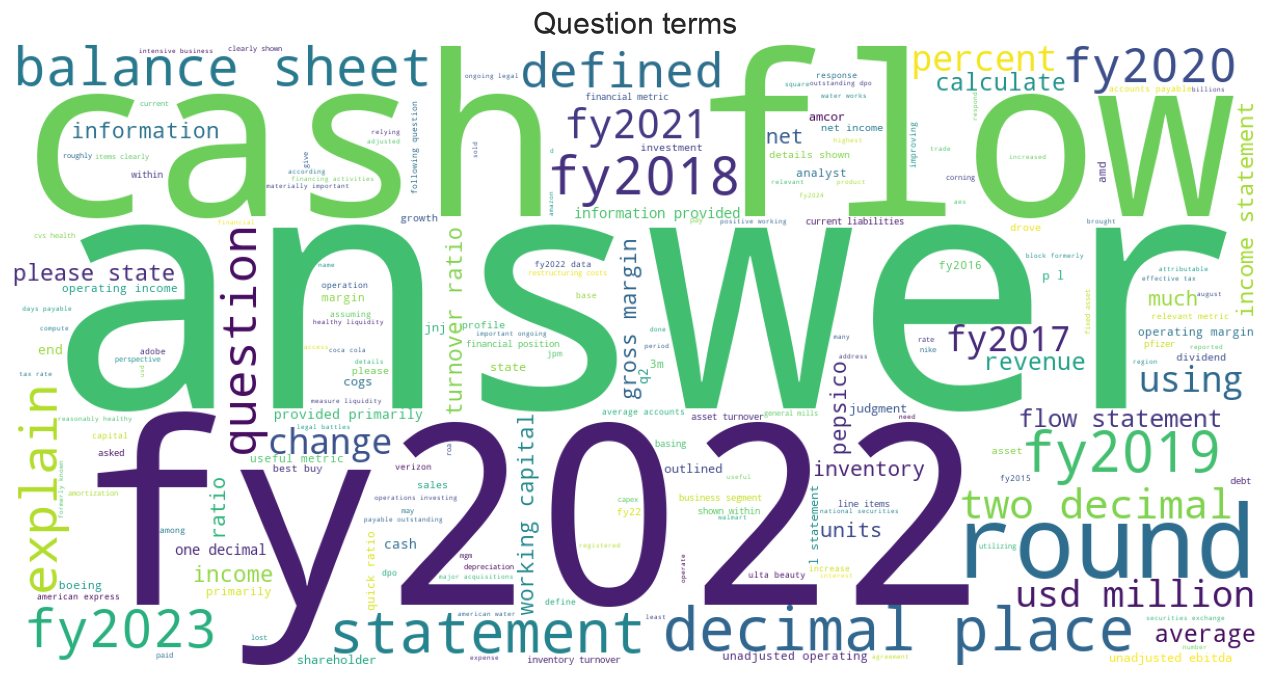

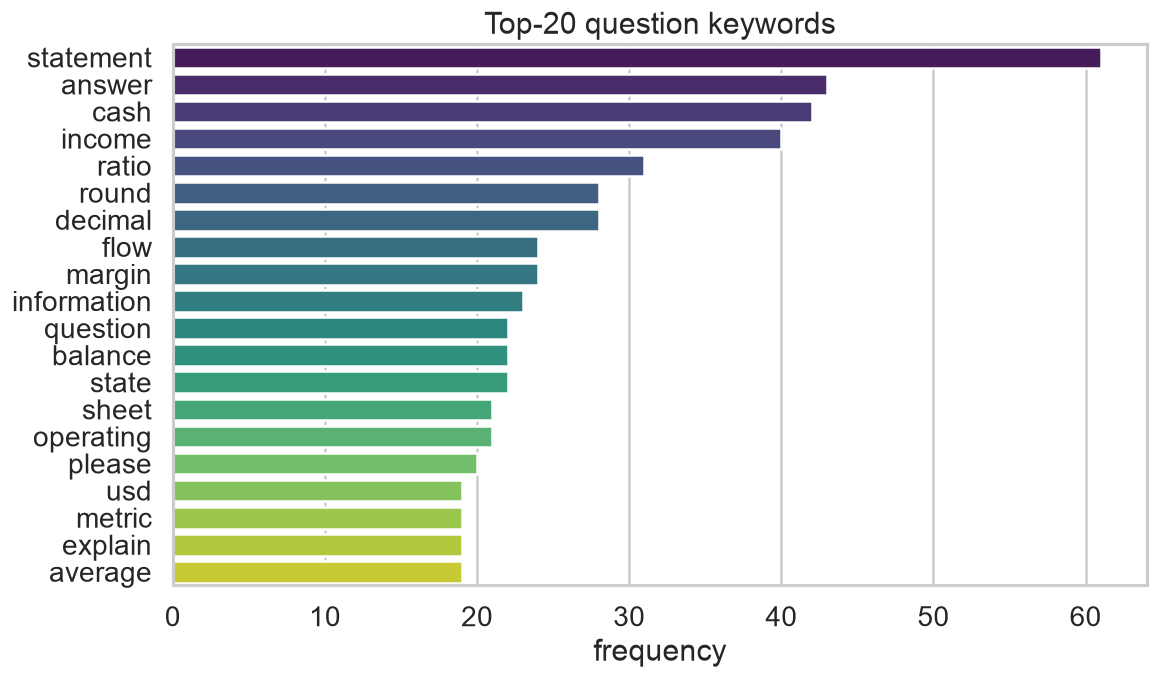

In [8]:
# Keyword frequency + wordcloud over question text
from wordcloud import WordCloud, STOPWORDS
stop = set(STOPWORDS) | {"company", "fiscal", "year", "fy", "did", "based", "would", "given",
                          "use", "us", "amount", "value", "total", "report", "10k", "10q"}
text = " ".join(qa["question"].astype(str)).lower()
wc = WordCloud(width=1200, height=600, background_color="white", stopwords=stop,
               colormap="viridis").generate(text)
fig, ax = plt.subplots(figsize=(12, 6)); ax.imshow(wc); ax.axis("off")
ax.set_title("Question terms")
save(fig, "fig_wordcloud.png"); plt.show()

tokens = [w for w in re.findall(r"[a-z]+", text) if w not in stop and len(w) > 2]
top = Counter(tokens).most_common(20)
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=[c for _, c in top], y=[w for w, _ in top], palette=PALETTE, orient="h", ax=ax)
ax.set_title("Top-20 question keywords"); ax.set_xlabel("frequency"); ax.set_ylabel("")
save(fig, "fig_keywords.png"); plt.show()

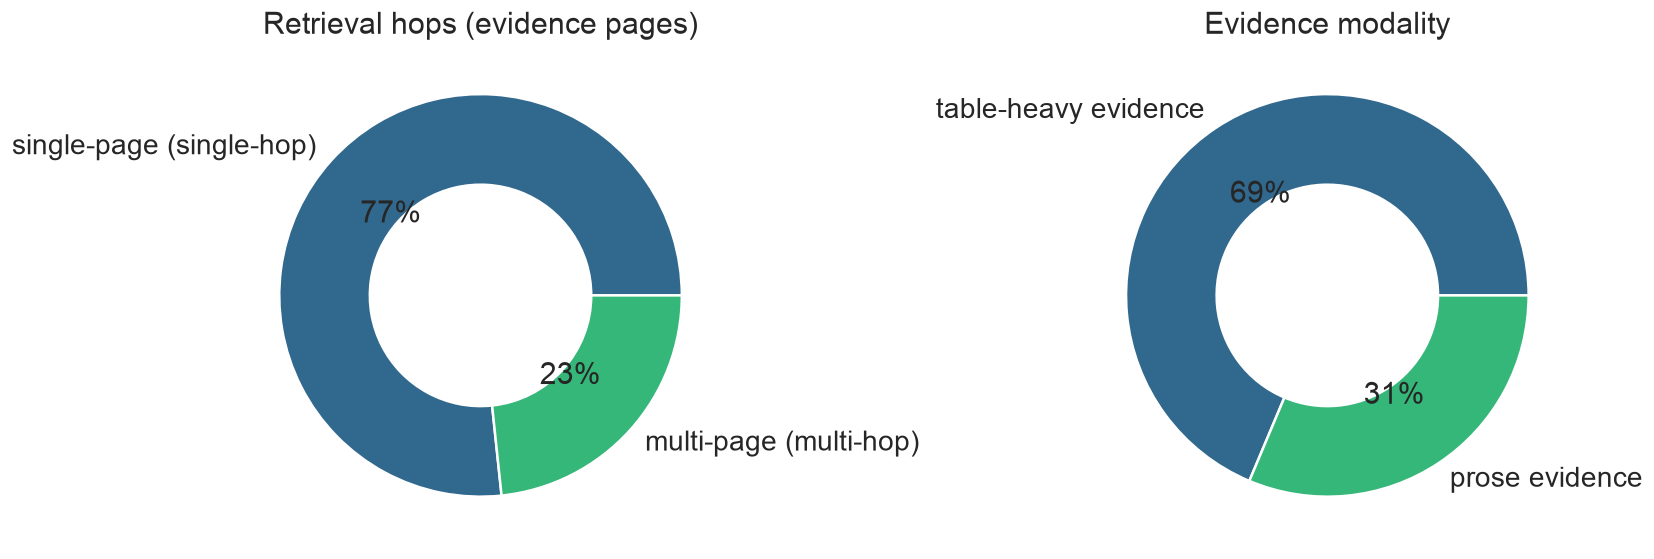

multi-page questions: 35 | table-heavy evidence: 103


In [9]:
# Single-hop vs multi-hop, and table-vs-text retrieval demand
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
hop = qa["multi_page"].map({False: "single-page (single-hop)", True: "multi-page (multi-hop)"}).value_counts()
axes[0].pie(hop.values, labels=hop.index, autopct="%1.0f%%", colors=sns.color_palette(PALETTE, 2),
            wedgeprops=dict(width=0.45))
axes[0].set_title("Retrieval hops (evidence pages)")
tbl = qa["evidence_is_table"].map({True: "table-heavy evidence", False: "prose evidence"}).value_counts()
axes[1].pie(tbl.values, labels=tbl.index, autopct="%1.0f%%", colors=sns.color_palette(PALETTE, 2),
            wedgeprops=dict(width=0.45))
axes[1].set_title("Evidence modality")
save(fig, "fig_hop_table.png"); plt.show()
print("multi-page questions:", int(qa["multi_page"].sum()), "| table-heavy evidence:", int(qa["evidence_is_table"].sum()))

## 3. Answer analysis

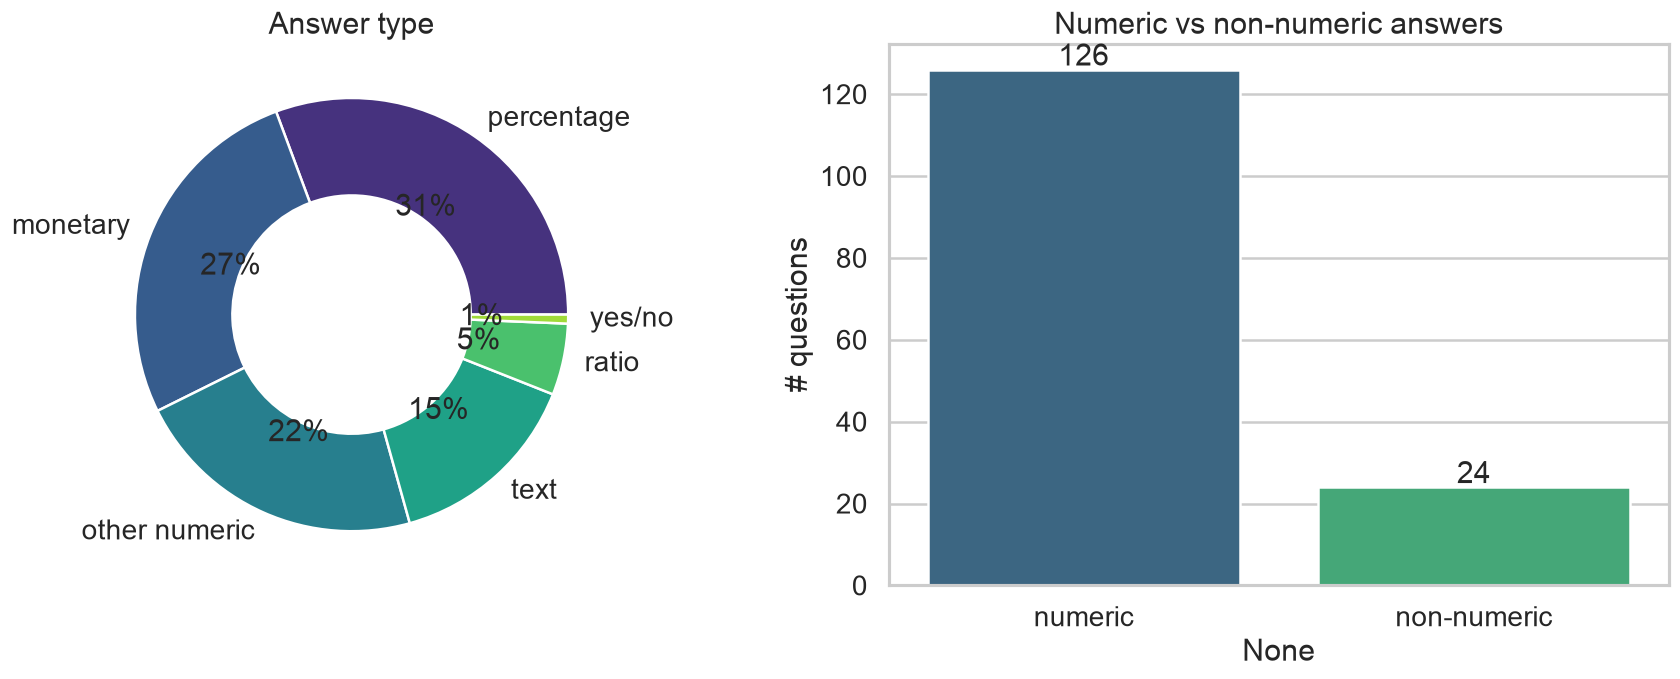

{'percentage': 46, 'monetary': 40, 'other numeric': 33, 'text': 22, 'ratio': 8, 'yes/no': 1}
currency/unit answers: 40 | percentage answers: 47

repeated answer strings (shared across >1 question): 1 -> {'there are none': 2}


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
at = qa["answer_type"].value_counts()
axes[0].pie(at.values, labels=at.index, autopct="%1.0f%%",
            colors=sns.color_palette(PALETTE, len(at)), wedgeprops=dict(width=0.45))
axes[0].set_title("Answer type")
num_split = pd.Series({"numeric": qa["is_numeric_answer"].sum(),
                       "non-numeric": (~qa["is_numeric_answer"]).sum()})
sns.barplot(x=num_split.index, y=num_split.values, palette=PALETTE, ax=axes[1])
axes[1].set_title("Numeric vs non-numeric answers"); axes[1].set_ylabel("# questions")
for i, v in enumerate(num_split.values):
    axes[1].text(i, v + 1, str(int(v)), ha="center")
save(fig, "fig_answer_type.png"); plt.show()
print(at.to_dict())
print("currency/unit answers:", int(qa["answer_has_currency"].sum()),
      "| percentage answers:", int(qa["answer_has_pct"].sum()))

# Answer uniqueness
dups = qa["answer"].astype(str).str.strip().str.lower().value_counts()
print("\nrepeated answer strings (shared across >1 question):", int((dups > 1).sum()),
      "->", dups[dups > 1].head(5).to_dict())

## 4. Evidence / context analysis

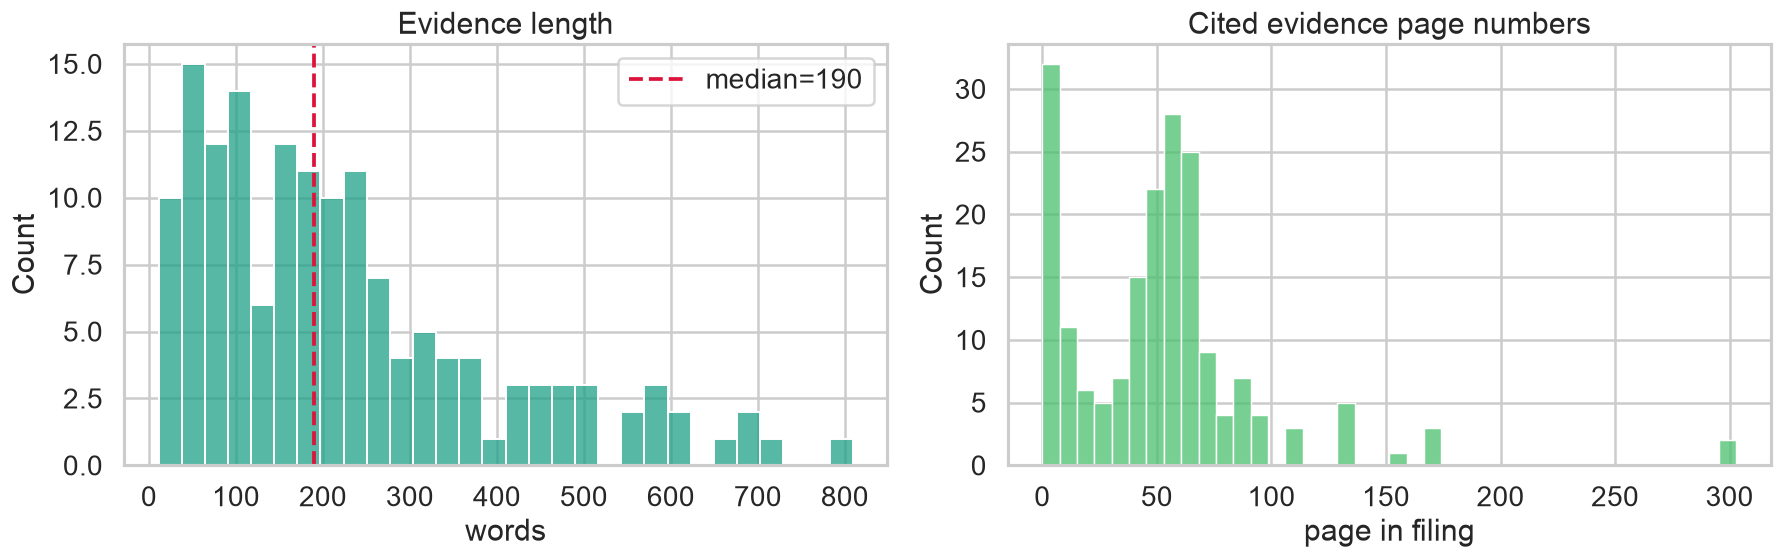

evidence items per question: {1: 115, 2: 31, 3: 4}
multi-page evidence: 35 | multi-document evidence: 0


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(qa["evidence_words"], bins=30, color=sns.color_palette(PALETTE)[3], ax=axes[0])
axes[0].axvline(qa["evidence_words"].median(), color="crimson", ls="--",
                label=f"median={qa['evidence_words'].median():.0f}")
axes[0].set_title("Evidence length"); axes[0].set_xlabel("words"); axes[0].legend()
all_pages = [p for plist in qa["evidence_pages"] for p in plist]
sns.histplot(all_pages, bins=40, color=sns.color_palette(PALETTE)[4], ax=axes[1])
axes[1].set_title("Cited evidence page numbers"); axes[1].set_xlabel("page in filing")
save(fig, "fig_evidence_length_pages.png"); plt.show()

loc = qa["n_evidence_items"].value_counts().sort_index()
print("evidence items per question:", loc.to_dict())
print("multi-page evidence:", int(qa["multi_page"].sum()),
      "| multi-document evidence:", int(qa["multi_document"].sum()))

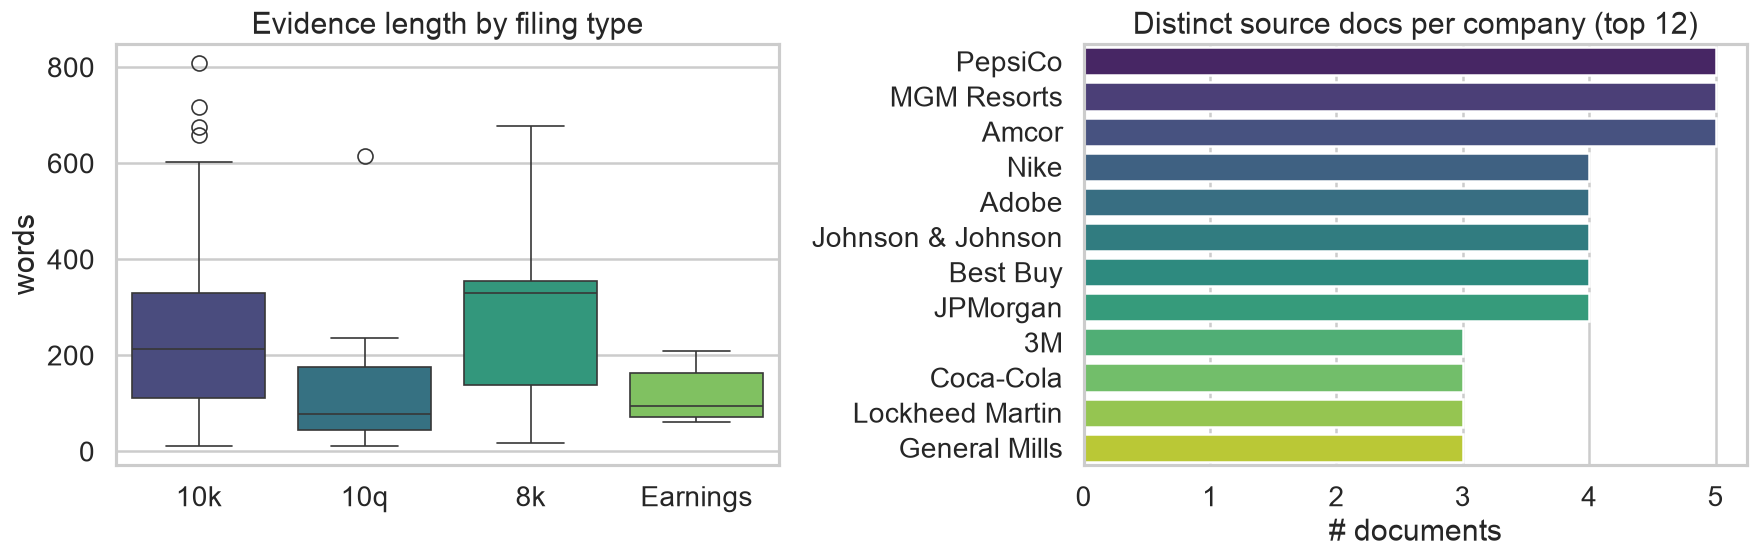

In [12]:
# Evidence length by filing type (boxplot) + evidence overlap per company
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=qa, x="doc_type", y="evidence_words", palette=PALETTE, ax=axes[0])
axes[0].set_title("Evidence length by filing type"); axes[0].set_xlabel(""); axes[0].set_ylabel("words")
qpc = qa.groupby("company")["doc_name"].nunique().sort_values(ascending=False).head(12)
sns.barplot(x=qpc.values, y=qpc.index, palette=PALETTE, orient="h", ax=axes[1])
axes[1].set_title("Distinct source docs per company (top 12)"); axes[1].set_xlabel("# documents"); axes[1].set_ylabel("")
save(fig, "fig_evidence_box_docspercompany.png"); plt.show()

## 5. Source-document characteristics

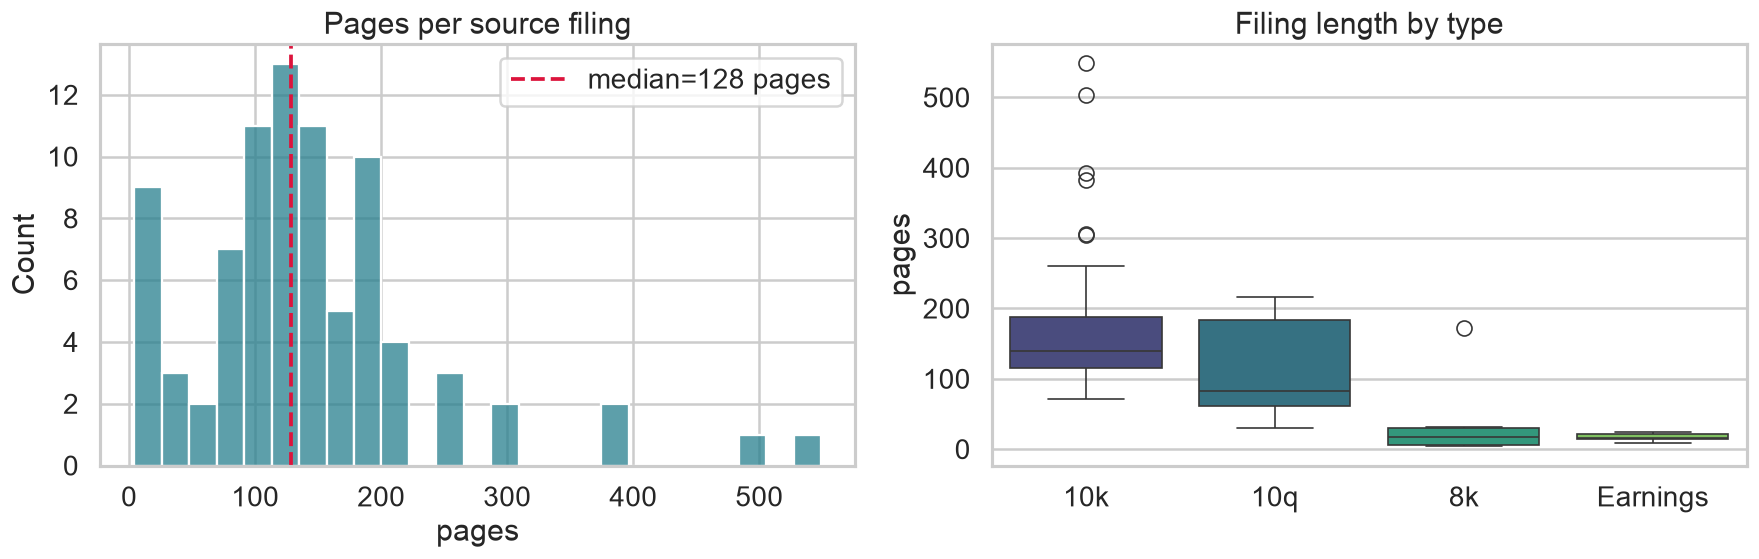

pages per filing: min/median/mean/max = 4 128 143.0 549


In [13]:
dp = qa.drop_duplicates("doc_name")[["doc_name", "doc_pages", "doc_type"]].dropna()
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(dp["doc_pages"], bins=25, color=sns.color_palette(PALETTE)[2], ax=axes[0])
axes[0].axvline(dp["doc_pages"].median(), color="crimson", ls="--",
                label=f"median={dp['doc_pages'].median():.0f} pages")
axes[0].set_title("Pages per source filing"); axes[0].set_xlabel("pages"); axes[0].legend()
sns.boxplot(data=dp, x="doc_type", y="doc_pages", palette=PALETTE, ax=axes[1])
axes[1].set_title("Filing length by type"); axes[1].set_xlabel(""); axes[1].set_ylabel("pages")
save(fig, "fig_doc_pages.png"); plt.show()
print("pages per filing: min/median/mean/max =",
      int(dp["doc_pages"].min()), int(dp["doc_pages"].median()),
      round(dp["doc_pages"].mean(), 1), int(dp["doc_pages"].max()))

## 6. Company & domain distribution

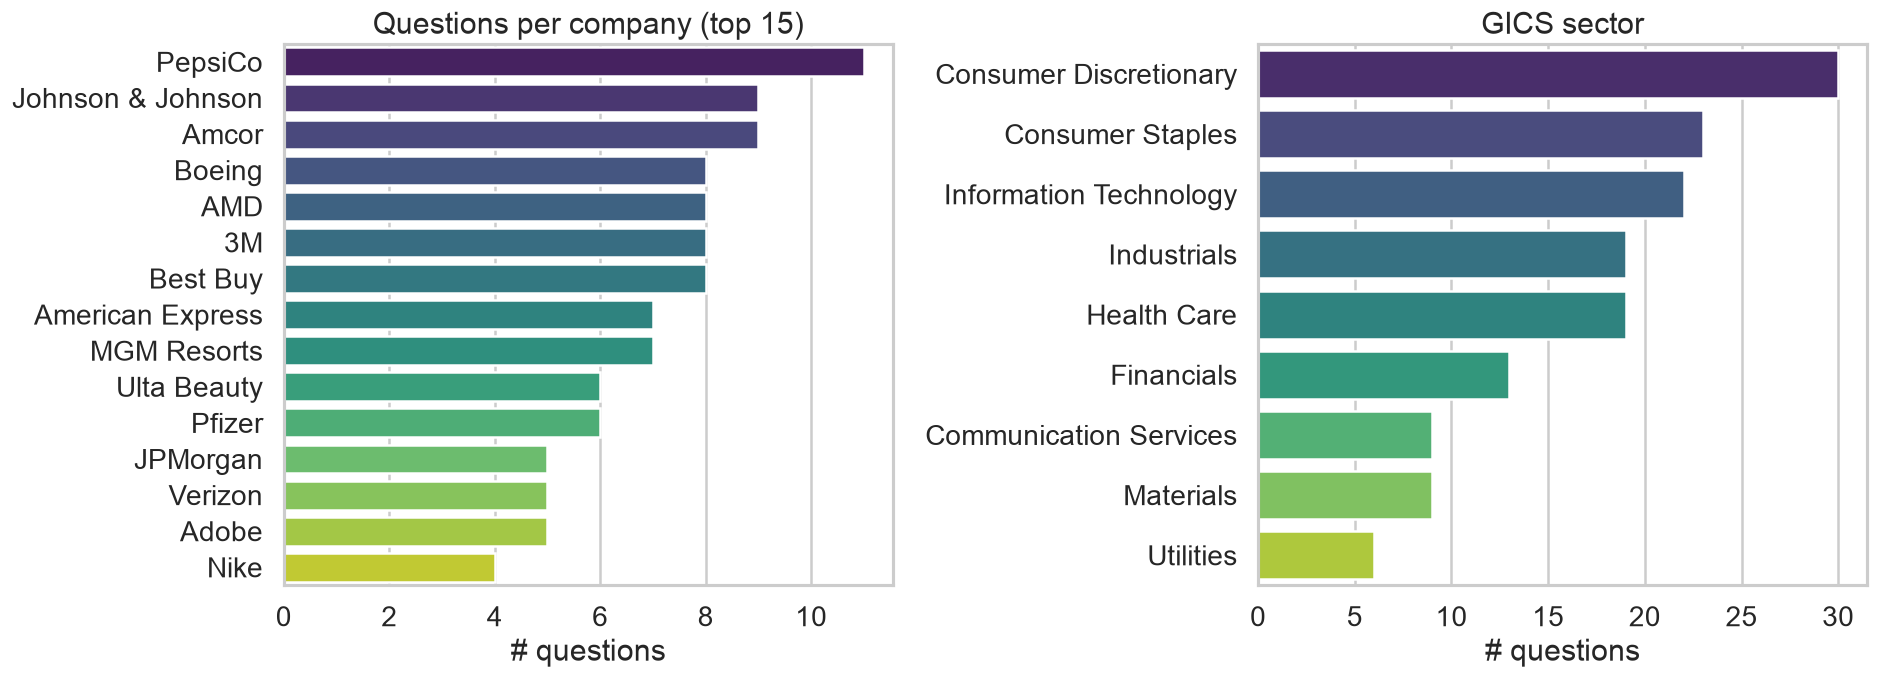

most/least represented company: PepsiCo 11 / Kraft Heinz 1


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
qpc = qa["company"].value_counts()
sns.barplot(x=qpc.head(15).values, y=qpc.head(15).index, palette=PALETTE, orient="h", ax=axes[0])
axes[0].set_title("Questions per company (top 15)"); axes[0].set_xlabel("# questions"); axes[0].set_ylabel("")
sec = qa["gics_sector"].value_counts()
sns.barplot(x=sec.values, y=sec.index, palette=PALETTE, orient="h", ax=axes[1])
axes[1].set_title("GICS sector"); axes[1].set_xlabel("# questions"); axes[1].set_ylabel("")
save(fig, "fig_company_sector.png"); plt.show()
print("most/least represented company:", qpc.idxmax(), int(qpc.max()), "/", qpc.idxmin(), int(qpc.min()))

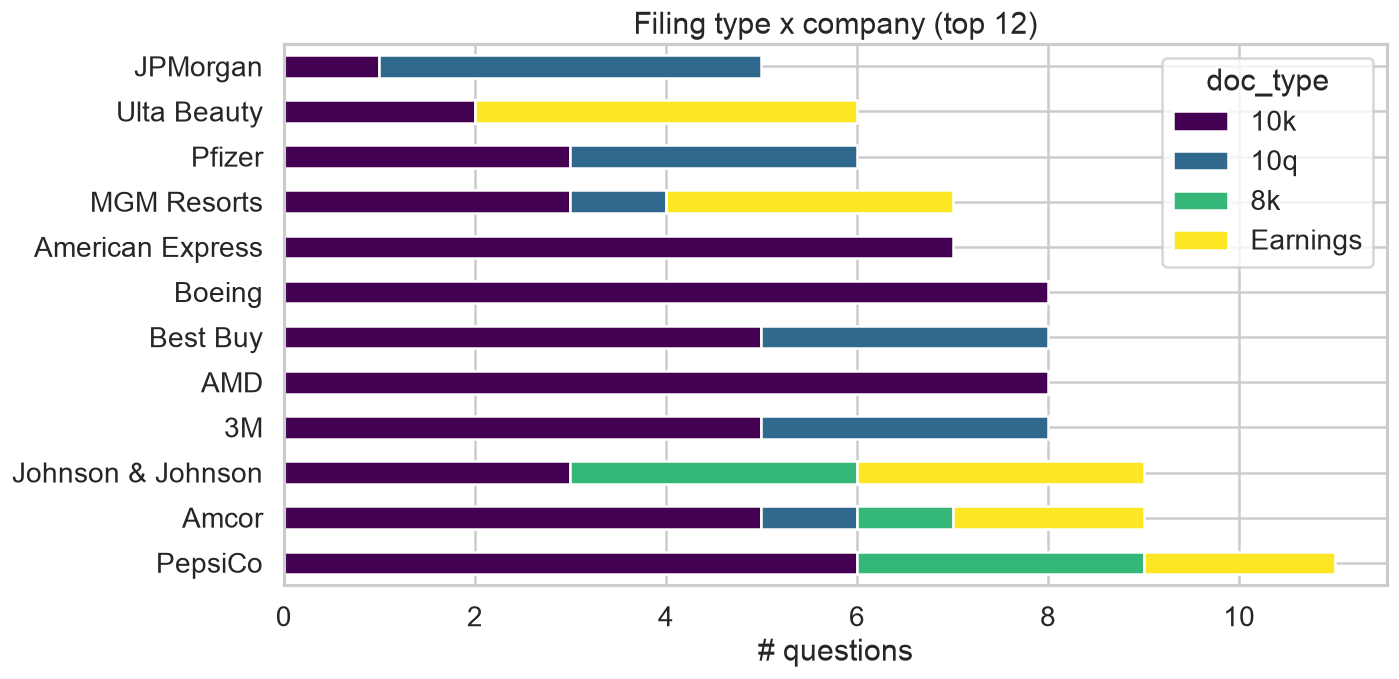

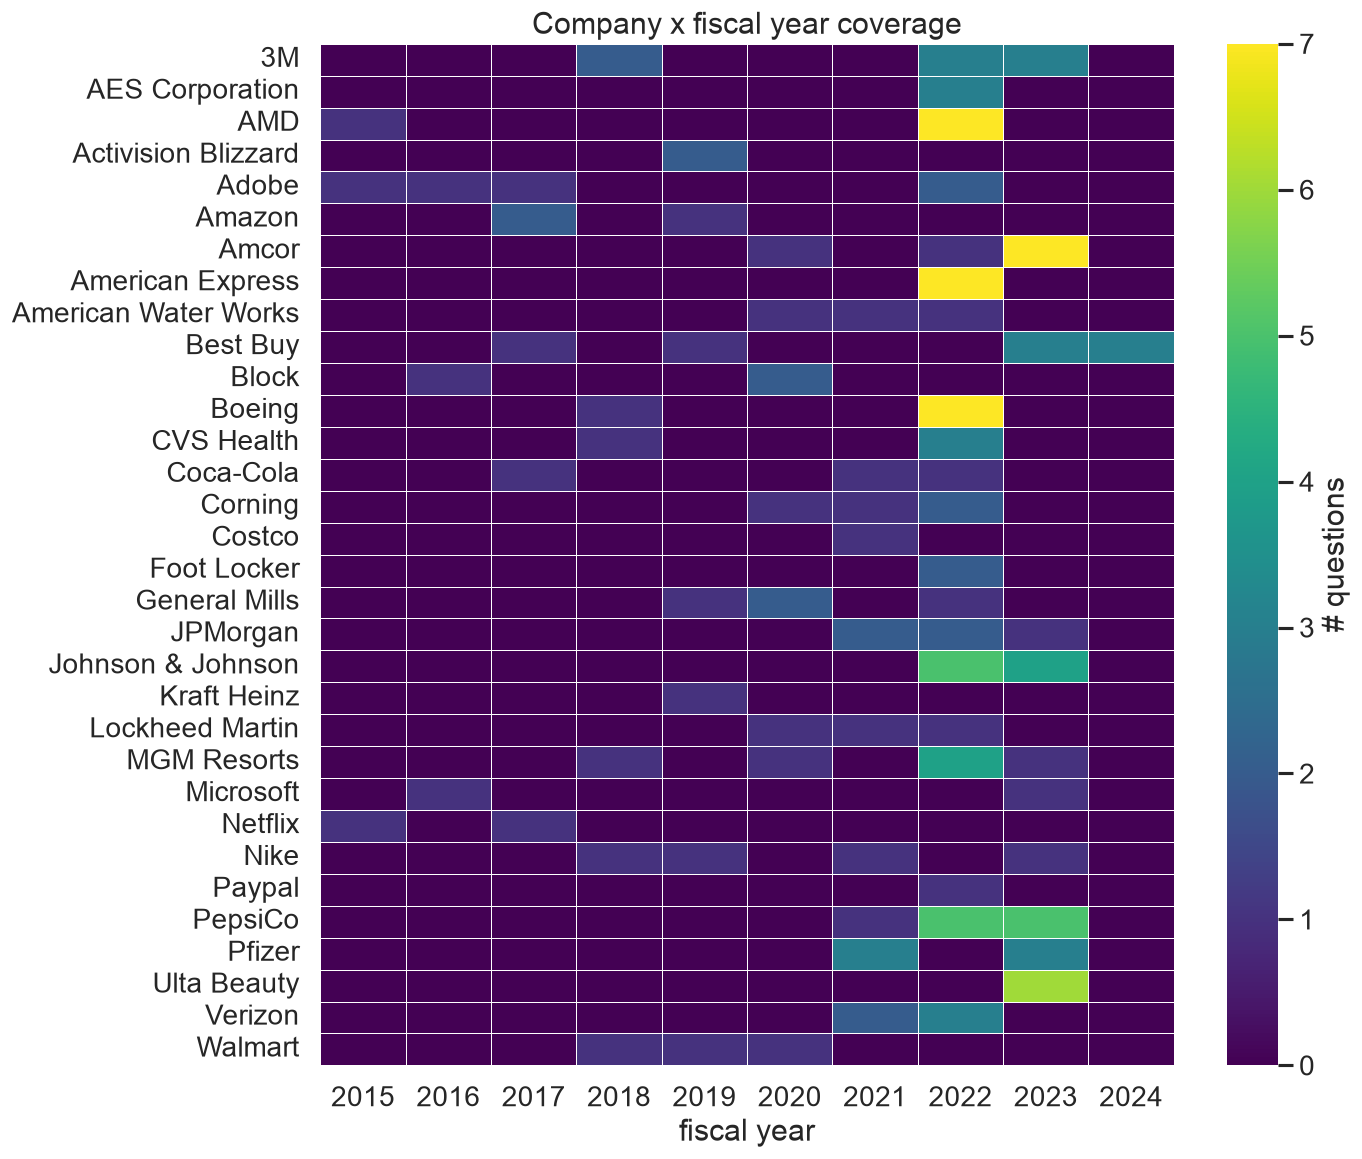

In [15]:
# Stacked bar: filing type x company (top companies) ; Heatmap: company x year
top_co = qa["company"].value_counts().head(12).index
ct = pd.crosstab(qa[qa["company"].isin(top_co)]["company"], qa["doc_type"])
ct = ct.loc[ct.sum(1).sort_values(ascending=False).index]
fig, ax = plt.subplots(figsize=(12, 6))
ct.plot(kind="barh", stacked=True, colormap="viridis", ax=ax)
ax.set_title("Filing type x company (top 12)"); ax.set_xlabel("# questions"); ax.set_ylabel("")
save(fig, "fig_filingtype_company_stacked.png"); plt.show()

heat = pd.crosstab(qa["company"], qa["doc_period"])
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(heat, cmap="viridis", linewidths=.4, cbar_kws={"label": "# questions"}, ax=ax)
ax.set_title("Company x fiscal year coverage"); ax.set_xlabel("fiscal year"); ax.set_ylabel("")
save(fig, "fig_company_year_heatmap.png"); plt.show()

## 7. Retrieval-difficulty indicators (hallucination-risk proxies)

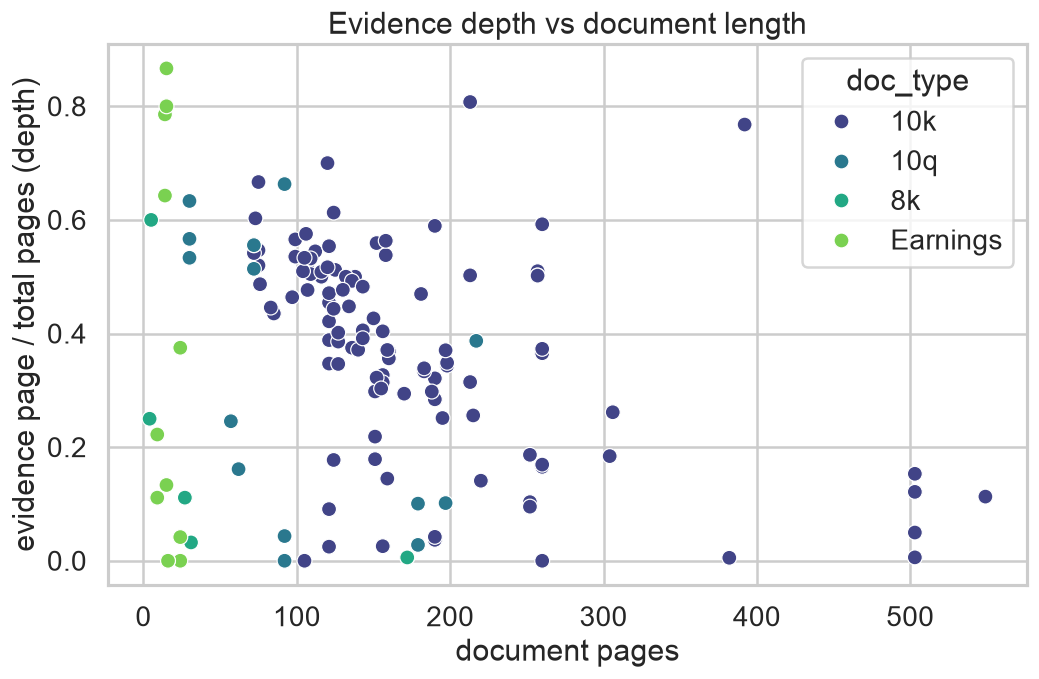

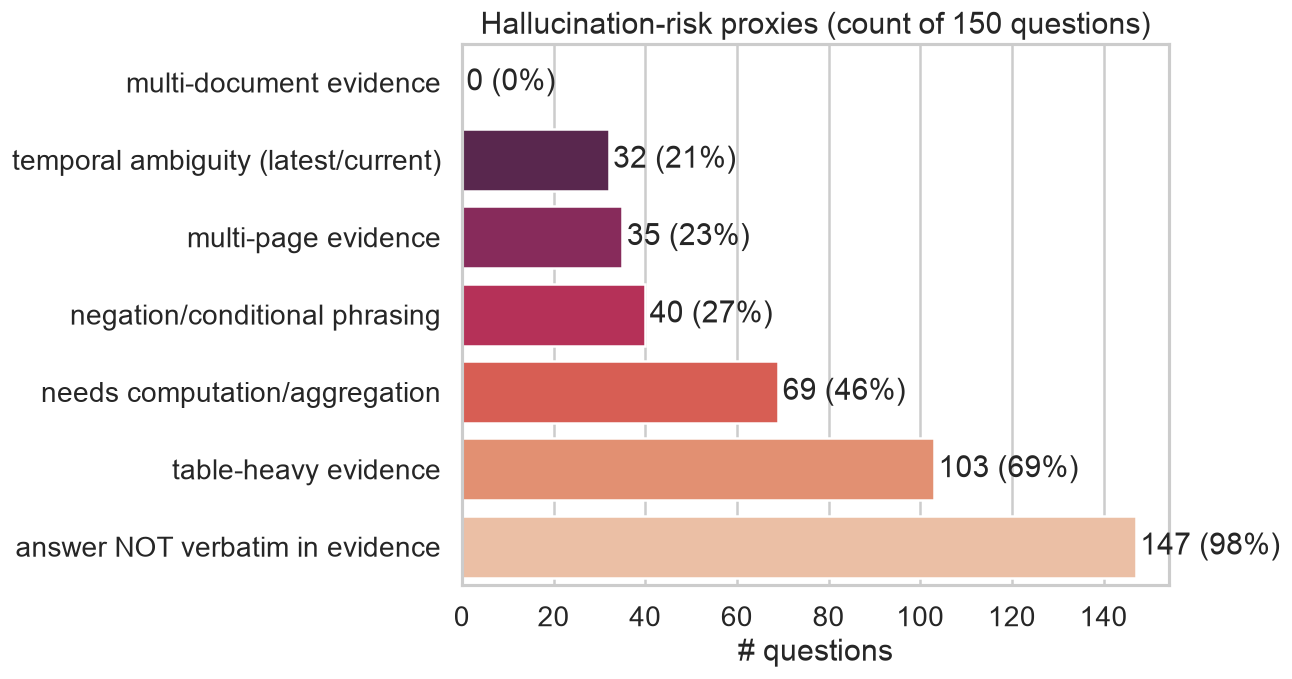

{'multi-page evidence': 35, 'multi-document evidence': 0, 'needs computation/aggregation': 69, 'temporal ambiguity (latest/current)': 32, 'negation/conditional phrasing': 40, 'table-heavy evidence': 103, 'answer NOT verbatim in evidence': 147}


In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
sub = qa.dropna(subset=["evidence_depth_ratio", "doc_pages"])
sns.scatterplot(data=sub, x="doc_pages", y="evidence_depth_ratio", hue="doc_type",
                palette=PALETTE, s=80, ax=ax)
ax.set_title("Evidence depth vs document length")
ax.set_xlabel("document pages"); ax.set_ylabel("evidence page / total pages (depth)")
save(fig, "fig_evidence_depth_scatter.png"); plt.show()

risk = {
    "multi-page evidence": int(qa["multi_page"].sum()),
    "multi-document evidence": int(qa["multi_document"].sum()),
    "needs computation/aggregation": int(qa["needs_computation"].sum()),
    "temporal ambiguity (latest/current)": int(qa["temporal_ambiguity"].sum()),
    "negation/conditional phrasing": int(qa["has_negation_conditional"].sum()),
    "table-heavy evidence": int(qa["evidence_is_table"].sum()),
    "answer NOT verbatim in evidence": int((~qa["answer_verbatim_in_evidence"]).sum()),
}
fig, ax = plt.subplots(figsize=(11, 6))
s = pd.Series(risk).sort_values()
sns.barplot(x=s.values, y=s.index, palette="rocket", orient="h", ax=ax)
for i, v in enumerate(s.values):
    ax.text(v + 1, i, f"{v} ({v/len(qa):.0%})", va="center")
ax.set_title("Hallucination-risk proxies (count of 150 questions)"); ax.set_xlabel("# questions"); ax.set_ylabel("")
save(fig, "fig_hallucination_risk.png"); plt.show()
print(risk)

## 8. Text complexity & linguistic analysis

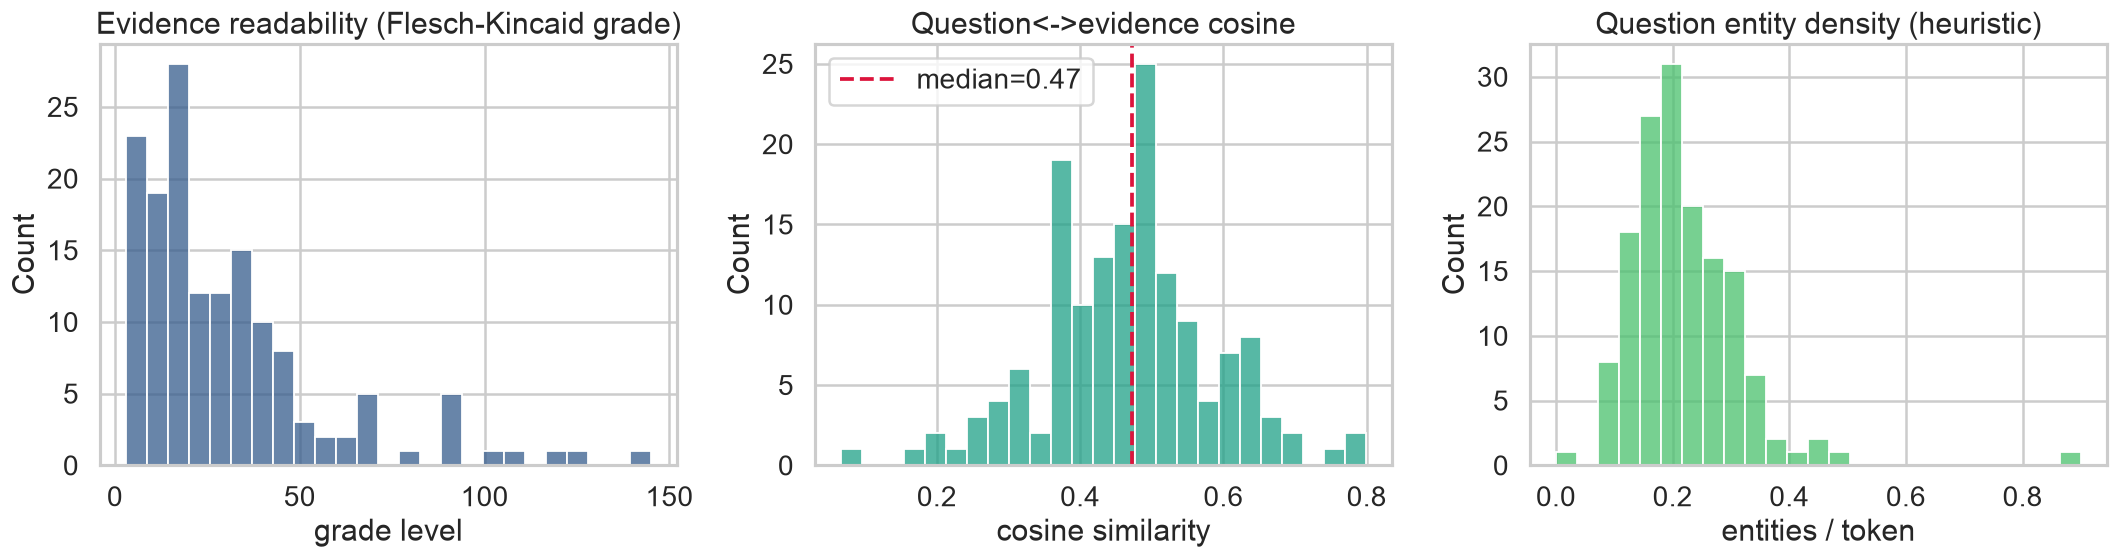

negation/conditional questions: 40 | median FK grade: 22.2 | median Q-E cosine: 0.47


In [17]:
import textstat
from sentence_transformers import SentenceTransformer, util

qa["evidence_fk_grade"] = qa["evidence_text_all"].apply(
    lambda t: textstat.flesch_kincaid_grade(t) if len(str(t).split()) > 3 else np.nan)

# Heuristic named-entity density in questions: $amounts, %, years, metric keywords, Proper Nouns
metric_kw = re.compile(r"\b(revenue|sales|ebitda|eps|margin|income|cash|debt|assets|dividend|capex|inventory)\b", re.I)
def entity_density(q):
    toks = str(q).split()
    if not toks:
        return 0.0
    ents = (len(re.findall(r"\$|%", q)) + len(re.findall(r"\b(19|20)\d{2}\b", q))
            + len(metric_kw.findall(q)) + sum(1 for t in toks[1:] if t[:1].isupper()))
    return ents / len(toks)
qa["entity_density"] = qa["question"].apply(entity_density)

# Q <-> evidence semantic similarity (MiniLM)
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")
q_emb = model.encode(qa["question"].tolist(), convert_to_tensor=True, show_progress_bar=False)
e_emb = model.encode(qa["evidence_text_all"].str.slice(0, 2000).tolist(),
                     convert_to_tensor=True, show_progress_bar=False)
qa["qe_cosine"] = [float(util.cos_sim(q_emb[i], e_emb[i])) for i in range(len(qa))]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(qa["evidence_fk_grade"].dropna(), bins=25, color=sns.color_palette(PALETTE)[1], ax=axes[0])
axes[0].set_title("Evidence readability (Flesch-Kincaid grade)"); axes[0].set_xlabel("grade level")
sns.histplot(qa["qe_cosine"], bins=25, color=sns.color_palette(PALETTE)[3], ax=axes[1])
axes[1].axvline(qa["qe_cosine"].median(), color="crimson", ls="--",
                label=f"median={qa['qe_cosine'].median():.2f}")
axes[1].set_title("Question<->evidence cosine"); axes[1].set_xlabel("cosine similarity"); axes[1].legend()
sns.histplot(qa["entity_density"], bins=25, color=sns.color_palette(PALETTE)[4], ax=axes[2])
axes[2].set_title("Question entity density (heuristic)"); axes[2].set_xlabel("entities / token")
save(fig, "fig_linguistic.png"); plt.show()
print("negation/conditional questions:", int(qa["has_negation_conditional"].sum()),
      "| median FK grade:", round(qa["evidence_fk_grade"].median(), 1),
      "| median Q-E cosine:", round(qa["qe_cosine"].median(), 2))

## 9. Missing data & quality checks

In [18]:
checks = {}
for col in ["question", "answer", "evidence", "doc_name", "doc_type", "doc_period", "gics_sector"]:
    checks[f"null `{col}`"] = int(qa[col].isna().sum())
checks["empty evidence list"] = int((qa["n_evidence_items"] == 0).sum())
checks["evidence with no page num"] = int((qa["evidence_pages"].apply(len) == 0).sum())
checks["duplicate questions (exact)"] = int(qa["question"].duplicated().sum())
norm_q = qa["question"].str.lower().str.replace(r"[^a-z0-9 ]", "", regex=True).str.strip()
checks["near-duplicate questions (normalized)"] = int(norm_q.duplicated().sum())
checks["answer NOT verbatim in evidence"] = int((~qa["answer_verbatim_in_evidence"]).sum())
checks["doc_name without matching PDF page count"] = int(qa["doc_pages"].isna().sum())
for k, v in checks.items():
    flag = "OK" if v == 0 else "review"
    print(f"[{flag:6s}] {k:45s}: {v}")

[OK    ] null `question`                              : 0
[OK    ] null `answer`                                : 0
[OK    ] null `evidence`                              : 0
[OK    ] null `doc_name`                              : 0
[OK    ] null `doc_type`                              : 0
[OK    ] null `doc_period`                            : 0
[OK    ] null `gics_sector`                           : 0
[OK    ] empty evidence list                          : 0
[OK    ] evidence with no page num                    : 0
[OK    ] duplicate questions (exact)                  : 0
[OK    ] near-duplicate questions (normalized)        : 0
[review] answer NOT verbatim in evidence              : 147
[OK    ] doc_name without matching PDF page count     : 0


## 10. Hallucination-specific pre-analysis

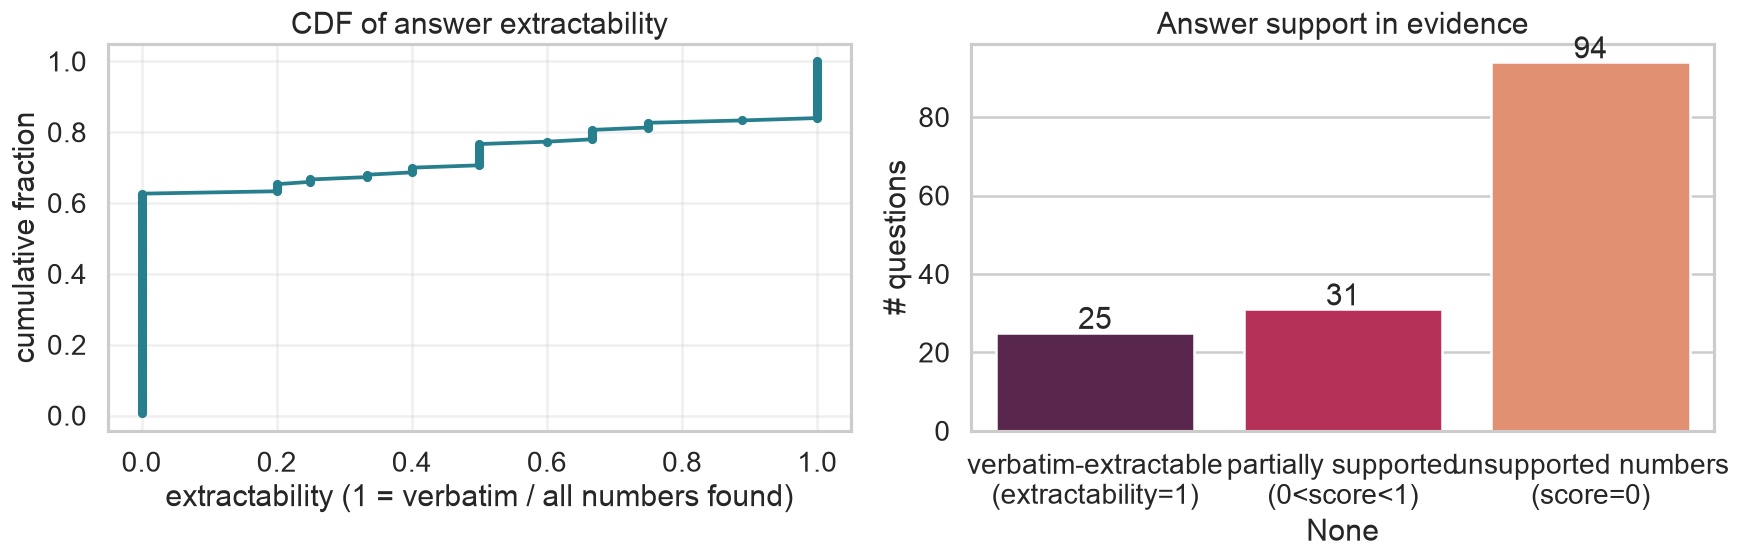

multi-document (highest-risk) questions: 0
answers with high numeric precision (>=2 decimals): 46
mean extractability: 0.27


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x = np.sort(qa["extractability"].values)
y = np.arange(1, len(x) + 1) / len(x)
axes[0].plot(x, y, marker=".", color=sns.color_palette(PALETTE)[2])
axes[0].set_title("CDF of answer extractability")
axes[0].set_xlabel("extractability (1 = verbatim / all numbers found)"); axes[0].set_ylabel("cumulative fraction")
axes[0].grid(True, alpha=.3)
prec = qa["answer"].apply(lambda a: bool(re.search(r"\d+\.\d{2,}", str(a))))
risk2 = pd.Series({
    "verbatim-extractable\n(extractability=1)": int((qa["extractability"] >= 0.999).sum()),
    "partially supported\n(0<score<1)": int(((qa["extractability"] > 0) & (qa["extractability"] < 0.999)).sum()),
    "unsupported numbers\n(score=0)": int((qa["extractability"] == 0).sum()),
})
sns.barplot(x=risk2.index, y=risk2.values, palette="rocket", ax=axes[1])
axes[1].set_title("Answer support in evidence"); axes[1].set_ylabel("# questions")
for i, v in enumerate(risk2.values):
    axes[1].text(i, v + 1, str(int(v)), ha="center")
save(fig, "fig_extractability_cdf.png"); plt.show()

print("multi-document (highest-risk) questions:", int(qa["multi_document"].sum()))
print("answers with high numeric precision (>=2 decimals):", int(prec.sum()))
print("mean extractability:", round(qa["extractability"].mean(), 2))

## 11. Paper Figure 1 — overview panel (kept for the prelim paper)

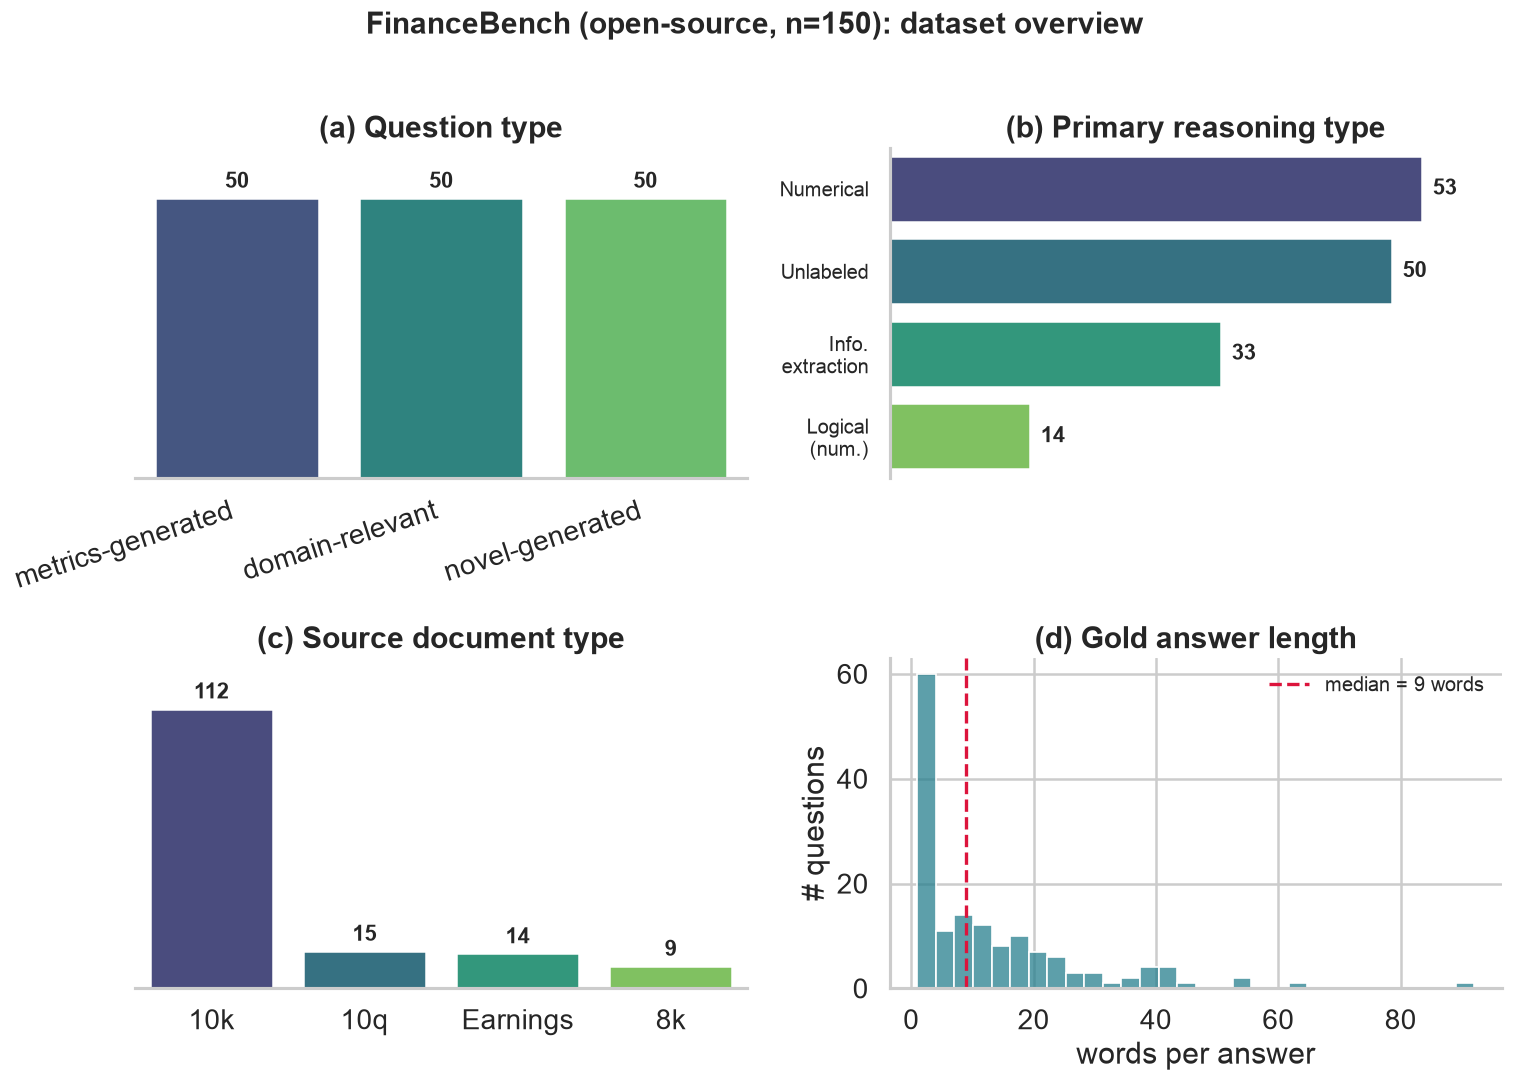

overview + standalone figures regenerated


In [20]:
import textwrap

# Paper Figure 1 — clean 2x2 overview: short/wrapped labels, counts on bars, no
# redundant "# questions" axes.
REASON_MAP = {
    "Numerical reasoning": "Numerical",
    "(unlabeled)": "Unlabeled",
    "Information extraction": "Info. extraction",
    "Logical reasoning (based on numerical reasoning)": "Logical (num.)",
}
_reason = (qa["question_reasoning"].fillna("(unlabeled)")
           .str.split(" OR ").str[0].map(lambda x: REASON_MAP.get(x, x)))

def _wrap(labels, width=10):
    return [textwrap.fill(str(t), width=width) for t in labels]

def _vbars(ax, counts, title, rotate=0):
    sns.barplot(x=counts.index, y=counts.values, palette=PALETTE, ax=ax)
    ax.set_title(title, fontweight="bold"); ax.set_xlabel(""); ax.set_ylabel("")
    ax.set_ylim(0, counts.max() * 1.18)
    for i, v in enumerate(counts.values):
        ax.text(i, v + counts.max() * 0.02, f"{int(v)}", ha="center", va="bottom",
                fontsize=13, fontweight="bold")
    ax.set_yticks([]); ax.tick_params(left=False)
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    if rotate:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=rotate, ha="right")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# (a) Question type
_vbars(axes[0, 0], qa["question_type"].value_counts(), "(a) Question type", rotate=18)

# (b) Primary reasoning type — horizontal, wrapped labels, counts at bar end
rc = _reason.value_counts()
sns.barplot(x=rc.values, y=_wrap(rc.index, 10), palette=PALETTE, orient="h", ax=axes[0, 1])
axes[0, 1].set_title("(b) Primary reasoning type", fontweight="bold")
axes[0, 1].set_xlabel(""); axes[0, 1].set_ylabel("")
axes[0, 1].set_xlim(0, rc.max() * 1.15); axes[0, 1].set_xticks([])
axes[0, 1].tick_params(axis="y", labelsize=12)
for j, v in enumerate(rc.values):
    axes[0, 1].text(v + rc.max() * 0.02, j, f"{int(v)}", va="center", fontsize=13, fontweight="bold")
for s in ("top", "right", "bottom"):
    axes[0, 1].spines[s].set_visible(False)

# (c) Source document type
_vbars(axes[1, 0], qa["doc_type"].value_counts(), "(c) Source document type")

# (d) Gold answer length — keep a light y-axis since it's a distribution
sns.histplot(qa["answer_words"], bins=30, color=sns.color_palette(PALETTE)[2],
             edgecolor="white", ax=axes[1, 1])
_med = qa["answer_words"].median()
axes[1, 1].axvline(_med, color="crimson", ls="--", lw=2, label=f"median = {_med:.0f} words")
axes[1, 1].set_title("(d) Gold answer length", fontweight="bold")
axes[1, 1].set_xlabel("words per answer"); axes[1, 1].set_ylabel("# questions")
axes[1, 1].legend(frameon=False, fontsize=12)
for s in ("top", "right"):
    axes[1, 1].spines[s].set_visible(False)

fig.suptitle("FinanceBench (open-source, n=150): dataset overview",
             fontsize=18, fontweight="bold", y=1.01)
fig.tight_layout(w_pad=3, h_pad=3)
save(fig, "fig_eda_overview.png"); plt.show()

# also keep individual standalone figures used earlier
for col, title, fname in [("question_type", "Question type", "fig_question_types.png"),
                          ("doc_type", "Source document type", "fig_doc_types.png"),
                          ("gics_sector", "GICS sector", "fig_sectors.png")]:
    c = qa[col].value_counts()
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.barplot(x=c.index, y=c.values, palette=PALETTE, ax=ax)
    ax.set_title(title); ax.set_ylabel("# questions"); ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
    save(fig, fname); plt.close(fig)
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(qa["answer_words"], bins=30, color=sns.color_palette(PALETTE)[2], ax=ax)
ax.set_title("Gold answer length"); ax.set_xlabel("words per answer")
save(fig, "fig_answer_length.png"); plt.close(fig)
rc2 = _reason.value_counts()
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(x=rc2.values, y=_wrap(rc2.index, 10), palette=PALETTE, orient="h", ax=ax)
ax.set_title("Primary reasoning type"); ax.set_xlabel("# questions")
save(fig, "fig_reasoning_types.png"); plt.close(fig)
print("overview + standalone figures regenerated")


## 12. Written summary for the paper
Writes `results/eda_summary.md`.

In [21]:
n = len(qa)
dp = qa.drop_duplicates("doc_name")["doc_pages"].dropna()
summary = f'''# EDA Summary - FinanceBench (open-source, n={n})

_Auto-generated by `notebooks/01_eda.ipynb` (Task T04). Figures under `results/`._

## Dataset at a glance
- **{n} QA pairs** across **{qa["company"].nunique()} companies** and **{qa["doc_name"].nunique()} filings**,
  fiscal years **{int(qa["doc_period"].min())}-{int(qa["doc_period"].max())}**; {qa["gics_sector"].nunique()} GICS sectors.
- Source filings are long: **{int(dp.median())} pages median** (range {int(dp.min())}-{int(dp.max())}).
- Filing mix: {", ".join(f"{k} ({v})" for k, v in qa["doc_type"].value_counts().items())}.

## Questions & answers
- Question types balanced 50/50/50; heuristic intent split:
  {", ".join(f"{k} ({v})" for k, v in qa["question_class"].value_counts().items())}.
- Dominant financial topics: {", ".join(f"{k} ({v})" for k, v in qa["topic"].value_counts().head(4).items())}.
- Answers are short (median {qa["answer_words"].median():.0f} words) and mostly **numeric**
  ({qa["is_numeric_answer"].mean():.0%}); {qa["answer_has_currency"].mean():.0%} carry currency/units.

## Evidence & retrieval difficulty
- Evidence is long (median {qa["evidence_words"].median():.0f} words) and frequently tabular
  ({qa["evidence_is_table"].mean():.0%} table-heavy).
- **{qa["multi_page"].mean():.0%}** of questions need multiple evidence pages (harder retrieval);
  evidence stays within a **single filing** per question in this open-source subset
  ({qa["multi_document"].mean():.0%} multi-document).
- Median question<->evidence cosine is **{qa["qe_cosine"].median():.2f}**, so lexical/semantic
  overlap is modest - retrievers must bridge a vocabulary gap.

## Hallucination pre-analysis (why this dataset is hard for RAG)
- Only **{qa["answer_verbatim_in_evidence"].mean():.0%}** of gold answers appear **verbatim** in the
  evidence; mean answer **extractability {qa["extractability"].mean():.2f}** - answers are largely
  *computed/abstractive*, not copy-paste. This is the core hallucination risk: the model must
  synthesize a value rather than extract it.
- {qa["needs_computation"].mean():.0%} of questions require numerical computation/aggregation;
  {qa["temporal_ambiguity"].mean():.0%} have temporal ambiguity; {qa["has_negation_conditional"].mean():.0%}
  use negation/conditional phrasing.

## Implications for our study
Long tabular 10-K context, short numeric *abstractive* answers, modest question-evidence overlap,
and a non-trivial share of multi-page questions make FinanceBench a stress test for
grounded generation. This justifies measuring **faithfulness (RAGAS)** alongside **F1/EM**, and our
4-category hallucination taxonomy (numerical, entity, reasoning, unsupported extrapolation).
'''
(RESULTS / "eda_summary.md").write_text(summary)
print(summary)

# EDA Summary - FinanceBench (open-source, n=150)

_Auto-generated by `notebooks/01_eda.ipynb` (Task T04). Figures under `results/`._

## Dataset at a glance
- **150 QA pairs** across **32 companies** and **84 filings**,
  fiscal years **2015-2024**; 9 GICS sectors.
- Source filings are long: **128 pages median** (range 4-549).
- Filing mix: 10k (112), 10q (15), Earnings (14), 8k (9).

## Questions & answers
- Question types balanced 50/50/50; heuristic intent split:
  numerical (61), multi-step reasoning (50), comparative (25), categorical/factual (14).
- Dominant financial topics: Other (34), Profit/Margin (24), Revenue/Sales (20), Assets/Balance Sheet (18).
- Answers are short (median 9 words) and mostly **numeric**
  (84%); 27% carry currency/units.

## Evidence & retrieval difficulty
- Evidence is long (median 190 words) and frequently tabular
  (69% table-heavy).
- **23%** of questions need multiple evidence pages (harder retrieval);
  evidence stays within a **single filing** pe